# POLONAISE UHDM limits: excluded $(m_\text{DM}, \alpha_n)$ regions

**Paper element.** Supplemental Material, Supplementary Limit Figures:
`01_excluded_massless` (the excluded region per mode for a massless mediator).
The same released surfaces will be behind the left panel of the Letter's results
figure once `scripts/paper_fig_limits.py` is moved off the internal capped,
100 GeV-window cube it still defaults to (see `notebooks/README.md`).

**Private.** The 95% CL exclusion limits for ultraheavy dark matter coupling to
neutrons through a finite-range Yukawa mediator, from the POLONAISE
levitated-magnet impulse search. The observed candidates are handled by the
public [`optimum_interval`](https://github.com/tunnell/optimum_interval) package
(Yellin optimum-interval; no background model needed).

**Sensor modes.** The excluded-region figures below show all three sensor modes
side by side; the remaining single-mode figures use `MODE_NUMBER` (set below:
1, 2, or 3). Each mode's inputs — the reconstructed impulse candidates
`data_mode{n}.txt` and the detection efficiency $\varepsilon(q)$, both shown and
checked in [`00_efficiency_and_blips.ipynb`](00_efficiency_and_blips.ipynb) —
are folded into the rate.
[`04_mode_comparison.ipynb`](04_mode_comparison.ipynb) overlays all three modes;
[`05_composite.ipynb`](05_composite.ipynb) combines them with the atmosphere
switched off.

**Fiducials** (threshold, live-time and $R_\text{eff}$ from `luhdm.config`): momentum threshold
$q_\text{th}$ = 1 TeV/$c$, live-time $T$ = 219.66 h (the measured dataset
exposure, `config.T_EXPOSURE`), sensor radius $R_\text{eff}$ = 260 µm, SHM halo
with atmospheric attenuation, and this species taken as $f_\mathrm{DM}$ = 1 of the local
dark-matter density. That last choice is now a property of the *file*: the
release ships one hypothesis per file and this notebook opens
`luhdm_datarelease_v8_A_f1_atm.h5`, the $f_\mathrm{DM}$ = 1, atmosphere-on
plane. The three physics mediator ranges $\lambda$ = 2 mm, 200 µm and 20 µm,
plus the analytic massless ($\lambda\to\infty$) limit, are drawn below; the
axis also carries a 200 m convergence-check slice, which is not a physics point
and is not drawn. Couplings up to $\alpha_n = 1$; masses up to the Planck mass.
The internal full-lambda cube behind the paper additionally scans 54 finite
ranges from 0.1 µm to 2 m; the one figure below that needs that continuous scan
is marked as such, is not regenerable from the released file, and is skipped
until such a cube exists in the scheme used here.

**The mass window.** Two edges of every region below come from outside the
extremeness surface. On the left, a hard kinematic wall at
$m_\text{wall} = q_\text{th}/v_\text{esc} = 5.51\times10^{5}$ GeV: no lighter
particle can deliver a 1 TeV kick at any coupling. On the right, the flux cut
$m_\text{cut}$: the impact-parameter integral is **uncapped** in this release,
so the surfaces keep reporting exclusion at masses where the halo delivers
almost no flybys through the apparatus, and the region is closed instead by
requiring $N_\text{req} = 3$ expected transits within 10 cm during the exposure
— **an assumption**, stated in the file's `m_cut_*` attributes and marked on
every mass-axis figure below. Nothing in the cube applies it for you.

**Output:** the figures below; every surface and contour behind them is
available in the POLONAISE UHDM data release (see
[`06_datarelease.ipynb`](06_datarelease.ipynb)), so nothing needs digitizing.

Companion notebooks: [`02_methodology.ipynb`](02_methodology.ipynb) (the physics
and statistics pipeline, with validations) and
[`03_understanding.ipynb`](03_understanding.ipynb) (why the excluded region looks
the way it does). All surfaces below come from the POLONAISE UHDM **data release**
(file A of the current release — see the version tag in the file /
`release/README.md`),
read through `luhdm.release`. See [`06_datarelease.ipynb`](06_datarelease.ipynb) for
the release schema and loader.

In [1]:
# ===== CONFIG: which sensor mode this notebook analyses =====
MODE_NUMBER = 1   # 1, 2, or 3

%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from luhdm import config, units
from luhdm import release

# File A of the released pair: f_DM = 1 with atmospheric attenuation, the
# plane the Letter quotes its alpha_n limits on. Its lambda axis carries the
# three physics ranges, the 200 m convergence slice and the massless sentinel.
# The separate internal full-lambda cube (luhdm.release.DEFAULT_PATH) is an
# older build; the last cell checks its scheme before drawing anything from it.
rel = release.open_release("../release/luhdm_datarelease_v8_A_f1_atm.h5")

R_eff = config.R_EFF             # 260 um
Q_THRESH = config.Q_THRESH          # 1 TeV analysis threshold
T_TOTAL = config.T_EXPOSURE     # dataset live-time; env-overridable via
                                 # LUHDM_T_EXPOSURE, currently the
                                 # night-selection exposure (219.66 h)
CONFIDENCE = 0.95
# Presentation convention for the Letter: every limit we quote is at a dark
# matter fraction f_DM = 1. Only the composite-DM benchmark departs from it
# (notebook 05, f_DM = 0.1, which is file B). File A carries the f_DM = 1
# plane and nothing else, so this is threaded into every rel.* call below
# rather than left to the loader default -- that default is the build-side
# baseline 0.1, which is not on this file's axis at all.
F_DM = 1.0
F_DM_TXT = r"$f_\mathrm{DM}$ = 1"
M_PLANCK = 1.22e19               # GeV
M_WALL = Q_THRESH / config.VESC  # kinematic wall, GeV: no lighter mass can
                                 # deliver a threshold kick at any coupling
# the halo flux cut that closes every region on the right. Stored as an
# attribute rather than baked into the surfaces, because the N_req = 3
# transits-within-10-cm standard it assumes is a choice, not a measurement.
M_CUT = next(float(v) for k, v in rel.attrs.items()
             if k.startswith("m_cut_") and k.endswith("_gev"))
N_REQ = float(rel.attrs["m_cut_n_transits_required"])
# x-axis top for the mass figures: one partial decade past m_Pl, so the
# Planck marker line falls inside the frame instead of on the right spine
XMAX_MASS = 3e19                 # GeV

# the release's three finite mediator ranges, largest first. The family is
# ordered in
# lambda, so it gets a sequential blue-to-green ramp (truncated viridis:
# monotone lightness survives black-and-white printing and is colorblind-safe,
# and it contains no red, which is reserved for the events / 95% contour).
_TAGS = ["2mm", "200um", "20um"]
_LAMBS = [2e-3, 2e-4, 2e-5]
_RAMP = plt.cm.viridis(np.linspace(0.02, 0.78, len(_TAGS)))
LAMBDAS = list(zip(_TAGS, _LAMBS, [tuple(c) for c in _RAMP]))
HIDE = set()                     # every released range is drawn
LAMB_REF = 2e-4                  # reference range for the detailed figures

def lamb_label(lamb_m):
    # mediator range in SI and natural units, for plot labels
    x = units.conv_m2pGeV(lamb_m)
    e = int(np.floor(np.log10(x)))
    if lamb_m >= 1:
        si = f"{lamb_m:.0f} m"
    elif lamb_m >= 1e-2:
        si = f"{lamb_m * 1e2:.0f} cm"
    elif lamb_m >= 1e-3:
        si = f"{lamb_m * 1e3:.0f} mm"
    else:
        si = f"{lamb_m * 1e6:.3g} µm"
    return rf"$\lambda$ = {si}"


def mphi_label(lamb_m, unit="eV"):
    # mediator mass m_phi = hbar c / lambda
    m_phi = 1.0 / units.conv_m2pGeV(lamb_m)
    if unit == "eV":
        m_phi *= 1e9
    e = int(np.floor(np.log10(m_phi)))
    return rf"$m_\phi$ = ${m_phi / 10**e:.1f}\times10^{{{e}}}$ {unit}"


def range_legend(lamb_m):
    # legend entry: range and the corresponding mediator mass (in eV)
    return lamb_label(lamb_m).split(" = $")[0] + ", " + mphi_label(lamb_m)


# SI-prefix milestones on a DM-mass axis (masses in GeV; names in eV prefixes)
MASS_MILESTONES = [(1e6, "PeV"), (1e9, "EeV"), (1e12, "ZeV"), (1e15, "YeV")]

def mark_mass_milestones(ax, m_lo, m_hi):
    import matplotlib.patheffects as _pe
    for m_gev, name in MASS_MILESTONES:
        if m_lo < m_gev < m_hi:
            ax.axvline(m_gev, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            txt = ax.text(m_gev, 0.015, f" {name}", color="#555555",
                          fontsize=9, ha="left", va="bottom", rotation=90,
                          zorder=1.5,   # under contour lines: halo must not notch them
                          transform=ax.get_xaxis_transform())
            txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                                  _pe.Normal()])


def mark_m_cut(ax, m_cut=None, y=0.985):
    # the flux cut: right-hand edge of every region drawn here. Everything to
    # its right is a statement about a flux the halo does not deliver.
    import matplotlib.patheffects as _pe
    m_cut = M_CUT if m_cut is None else m_cut
    ax.axvline(m_cut, color="#8c564b", lw=1.3, ls=(0, (6, 3)), zorder=1)
    txt = ax.text(m_cut, y, r"$m_{\mathrm{cut}}$ ", color="#8c564b",
                  fontsize=9, ha="right", va="top", rotation=90,
                  zorder=1.5,   # under contour lines: halo must not notch them
                  transform=ax.get_xaxis_transform())
    txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                          _pe.Normal()])


def mark_planck_mass(ax, m_pl=M_PLANCK, y=0.015, va="bottom"):
    # the mass grid stops at the Planck mass: mark that endpoint (label inside)
    import matplotlib.patheffects as _pe
    ax.axvline(m_pl, color="#555555", lw=1.3, ls=":", zorder=1)
    txt = ax.text(m_pl, y, r"$m_{\mathrm{Pl}}$", color="#555555",
                  fontsize=9, ha="right", va=va, rotation=90,
                  zorder=1.5,   # under contour lines: halo must not notch them
                  transform=ax.get_xaxis_transform())
    txt.set_path_effects([_pe.Stroke(linewidth=2.2, foreground="w"),
                          _pe.Normal()])


import os as _os
for _d in ("png", "svg", "pdf"):
    _os.makedirs(_d, exist_ok=True)

def save_figure(fig, name, stamp=None, **kw):
    # every figure lands in png/, svg/, and pdf/ with a notebook-number
    # prefix, stamped with the data-release version that produced it so
    # a figure always names its cube (pass stamp= for a figure drawn from
    # some cube other than the released one this notebook opens)
    fig.text(0.995, 0.004,
             f"POLONAISE UHDM data release {stamp or rel.version_tag}",
             ha="right", va="bottom", fontsize=6, color="#9a9a9a")
    for ext in ("png", "svg", "pdf"):
        fig.savefig(f"{ext}/{name}.{ext}", dpi=140, **kw)

print(f"N_n = {config.N_NEUTRONS:.2e}   q_th = {Q_THRESH:.0f} GeV   "
      f"R_eff = {R_eff * 1e6:.0f} um   f_DM = {F_DM:g} "
      f"(file axis {rel.f_dm_values})")
print(f"mass window: kinematic wall {M_WALL:.3g} GeV .. flux cut "
      f"{M_CUT:.3g} GeV (N_req = {N_REQ:g} transits within "
      f"{rel.attrs['m_cut_b_cap_m']:g} m -- an assumption, see "
      f"release/README.md section 5.4)")

N_n = 1.07e+20   q_th = 1000 GeV   R_eff = 260 um   f_DM = 1 (file axis [1.0])
mass window: kinematic wall 5.51e+05 GeV .. flux cut 6.11e+14 GeV (N_req = 3 transits within 0.1 m -- an assumption, see release/README.md section 5.4)


## Input: the candidate list

This mode's observed impulses live in `data_mode{MODE_NUMBER}.txt` (one impulse
per line, in eV, `#` comments allowed): the blips above the 100 GeV/$c$
reconstruction threshold, written by the night-selection pipeline upstream of
this repository and displayed
in [`00_efficiency_and_blips.ipynb`](00_efficiency_and_blips.ipynb). To re-run on
updated data, replace that file and re-execute; nothing else changes. The values
used below are read from the data release via `rel.events(MODE_NUMBER)` and
cross-checked against `data_mode{MODE_NUMBER}.txt` when that file is present.
The 1 TeV/$c$ analysis window is applied by the limit calculation, through the
support of the signal spectrum, rather than by pre-cutting these lists: every
mode-1 candidate is above it, and the two sub-TeV mode-2 impulses simply never
enter an interval.

In [2]:
DATA = Path(f"data_mode{MODE_NUMBER}.txt")
EVENTS = rel.events(MODE_NUMBER)   # observed impulse candidates [GeV]
if DATA.exists():   # cross-check the release against this mode's input file
    assert np.allclose(EVENTS, np.loadtxt(DATA) / 1e9), \
        f"{DATA}: candidate list differs from the data release"
print(f"observed kicks [GeV]: {np.round(EVENTS, 1)}")

observed kicks [GeV]: [12790.7  6905.1  3509.6  3252.4  2862.   2033.7  1729.4  1520.7]


## The scans

One scan per mediator range from `scripts/scan_grid.py`, each a full
$(m_\text{DM}, \alpha_n)$ grid computed with this mode's candidates and
efficiency $\varepsilon(q)$ at the shared fiducials above. Each carries the
`extremeness` (the optimum-interval statistic; its meaning is unpacked in
[`02_methodology.ipynb`](02_methodology.ipynb)), the expected counts, and the
transit counts.

In [3]:
SCANS = {}
ALL_TAGS = LAMBDAS + [("massless", None, "k")]
for tag, lamb, color in ALL_TAGS:
    # every (m_DM, alpha_n) surface for this mode + range comes from the release
    SCANS[tag] = dict(
        ms=rel.axes.mass_gev,
        alphas_n=rel.axes.alpha_n,
        extremeness=rel.mass_plane("extremeness", MODE_NUMBER, tag,
                                   f_dm=F_DM),
        counts=rel.mass_plane("mu", MODE_NUMBER, tag, f_dm=F_DM),
        n_transit=rel.mass_plane("n_transit", lam=tag, f_dm=F_DM))
print(f"loaded {len(SCANS)} scans from the data release "
      f"({len(LAMBDAS)} ranges + massless)")

REF_TAG = "200um"
REF = SCANS[REF_TAG]

loaded 4 scans from the data release (3 ranges + massless)


## Results

### The excluded regions, mode by mode

Two three-panel figures — the reference finite range
$\lambda$ = 200 µm, then the massless ($\lambda\to\infty$)
mediator — with one panel per sensor mode (8, 26 and 126 candidates for modes
1, 2 and 3, night-time selection). Colour is the optimum-interval extremeness. Solid red: the 95% CL
contour for that mode's observed candidates. Dashed grey: the
$\langle N\rangle = 3$ contour (the naive zero-candidate rule) from the same
expected-count surface, drawn for comparison. The excluded region is bounded by
four edges — kinematic wall (left), statistics floor (bottom), atmospheric
ceiling (top, where there is one), and either reach saturation or the flux cut
(right); each is explained in
[`03_understanding.ipynb`](03_understanding.ipynb). The dashed brown line is
$m_\text{cut}$.

The right-hand edge is what separates the two figures, and it closes for a
different reason in each:

- **200 µm**: the island closes at $m \approx 7.1\times10^{10}$ GeV (mode 1),
  set by the **finite mediator range itself**. The saturated reach is only
  $\sim$0.4 cm, so this edge is in the surface and the flux cut is far off to
  the right, doing nothing.
- **massless**: Coulomb reach grows with $\alpha_n$ without bound and the
  impact-parameter integral is uncapped, so nothing in the surface stops the
  island — it runs to the Planck mass. What closes it is the **flux cut**
  $m_\text{cut} = 6.11\times10^{14}$ GeV, the mass beyond which the halo
  delivers fewer than $N_\text{req} = 3$ particles within 10 cm of the sensor
  during the exposure. It is identical in all three panels because it is a
  property of the flux, not of the candidate lists; only the interior of the
  island (and its floor) knows about the mode.

Where a candidate falls inside the (narrow) kinematic window at a given point,
the optimum-interval limit is weaker than the zero-candidate rule — the two
diverge near the floor and the left edge — because the zero-candidate rule
simply does not apply once there are events in the window. Where the window
excludes every candidate the two coincide; mode 3, with the most candidates,
shows the widest gap between the red and grey contours.

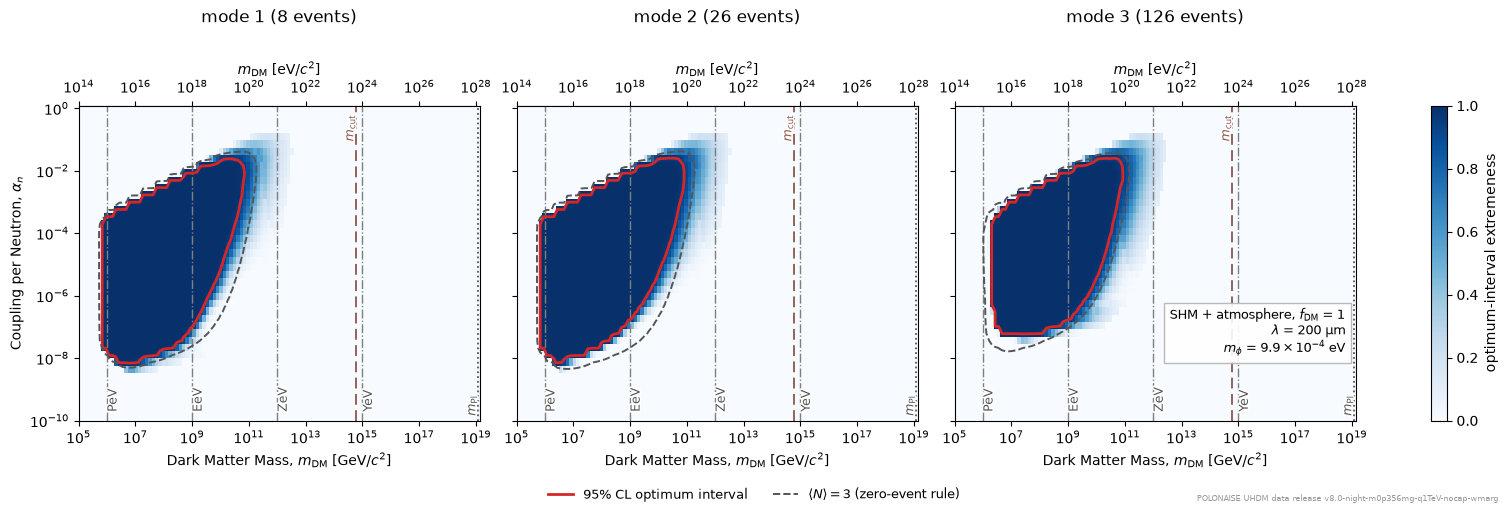

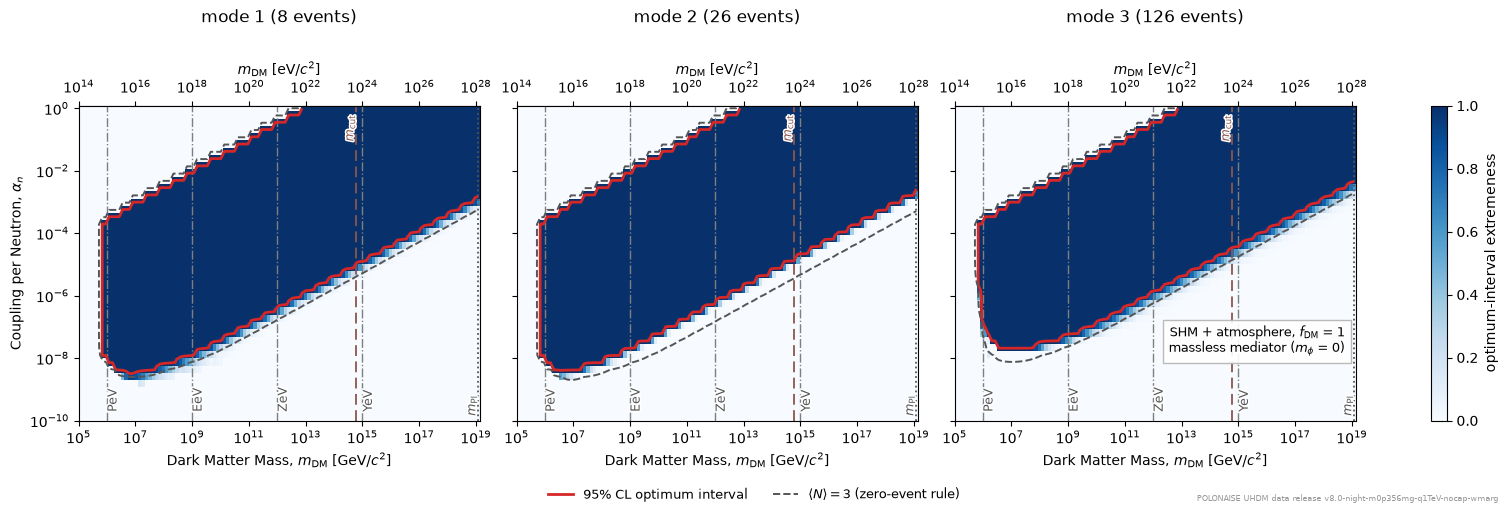

In [4]:
MODES = (1, 2, 3)   # every panel figure below shows all three sensor modes

def excluded_region_panels(tag, fname, info):
    """One panel per mode: extremeness plane, 95% CL and <N> = 3 contours."""
    ms, alphas_n = rel.axes.mass_gev, rel.axes.alpha_n
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True,
                             constrained_layout=True)
    for ax, mode in zip(axes, MODES):
        p = rel.mass_plane("extremeness", mode, tag, f_dm=F_DM)
        mu = rel.mass_plane("mu", mode, tag, f_dm=F_DM)
        mesh = ax.pcolormesh(ms, alphas_n, p, cmap="Blues", vmin=0, vmax=1,
                             shading="auto")
        ax.contour(ms, alphas_n, p, levels=[CONFIDENCE], colors="#d62728",
                   linewidths=2)
        ax.contour(ms, alphas_n, mu, levels=[3.0], colors="#555555",
                   linewidths=1.4, linestyles="--")
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
        mark_mass_milestones(ax, ms.min(), M_PLANCK)
        mark_m_cut(ax)
        mark_planck_mass(ax, ms[-1])
        sec = ax.secondary_xaxis("top", functions=(lambda x: x * 1e9,
                                                    lambda x: x / 1e9))
        sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
        ax.set_title(f"mode {mode} ({rel.events(mode).size} events)", pad=28)
    axes[0].set_ylabel(r"Coupling per Neutron, $\alpha_n$")
    fig.colorbar(mesh, ax=axes, label="optimum-interval extremeness")
    # one legend for the whole figure: the two contours mean the same thing
    # in every panel, so proxy lines on the first panel carry the labels
    axes[0].plot([], [], color="#d62728", lw=2,
                 label=f"{CONFIDENCE:.0%} CL optimum interval")
    axes[0].plot([], [], color="#555555", lw=1.4, ls="--",
                 label=r"$\langle N\rangle = 3$ (zero-event rule)")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center",
               ncols=2, fontsize=9, frameon=False)
    # info box once, in the last panel's empty high-mass / low-coupling corner
    axes[2].text(0.975, 0.20, info, transform=axes[2].transAxes,
                 ha="right", va="bottom", fontsize=9,
                 bbox=dict(fc="white", ec="0.7", alpha=0.9))
    save_figure(fig, fname)


excluded_region_panels(
    REF_TAG, "01_excluded_region_200um",
    f"SHM + atmosphere, {F_DM_TXT}\n"
    + lamb_label(LAMB_REF) + "\n"
    + mphi_label(LAMB_REF))
excluded_region_panels(
    "massless", "01_excluded_massless",
    f"SHM + atmosphere, {F_DM_TXT}\n"
    + r"massless mediator ($m_\phi$ = 0)")

### All released ranges

The 95% CL contours for the released finite ranges (2 mm, 200 µm, 20 µm), with
this mode's candidates and atmospheric attenuation everywhere, and the massless
analytic line dashed. The momentum cap
$\tilde q_\text{max} = K_1(\xi)$, $\xi = R_\text{eff}/\lambda$, organizes the
family:

- **Shared floor at long range.** Ranges in the Coulomb regime (mm and above)
  share a common coupling floor; shorter ranges pay the momentum-cap penalty
  and floor out higher — visible here as 20 µm flooring above 200 µm.
- **High-mass endpoints ladder with $\lambda$.** Reach saturates at
  $\sigma_\text{sat} \sim \lambda^2$ while the number density falls as $f_X/m$,
  so each decade of $\lambda$ buys roughly two decades of mass reach; every
  finite-range island closes below the Planck mass.
- **The massless analytic line (black dashed) is the $\lambda\to\infty$ ideal.**
  Its Coulomb reach grows as $\alpha$ without limit and this release does not
  truncate the impact-parameter integral, so the massless contour does not
  close on the right at all: it runs to the Planck mass. The dashed brown line
  is where the halo stops supplying $N_\text{req} = 3$ transits within 10 cm,
  $m_\text{cut} = 6.11\times10^{14}$ GeV, and that — not the surface — is the
  right-hand edge of the claim. The 200 m slice on the same axis is a
  convergence check on the finite-range branch: it lands on the massless
  contour and is not drawn here.
- **The shortest ranges exclude little or nothing.** As $\xi$ grows the
  saturated rate drops below the 95% exclusion bar; in the internal full-lambda
  scan the few-µm-and-below channels are honest nulls, not plotting gaps. The
  released cube carries the three finite slices above, which bracket that
  transition.

The floor values and high-mass endpoints are read straight off the figure and the
data release; they are not quoted here because they depend on the mode, its
candidate list, and the fiducials above.

   2mm: m in [6.8e+05, 5.7e+12] GeV, alpha_n down to 4.2e-09
 200um: m in [6.8e+05, 7.1e+10] GeV, alpha_n down to 7.3e-09
  20um: m in [9.0e+05, 6.6e+08] GeV, alpha_n down to 1.8e-07
massless: m in [6.8e+05, 1.2e+19] GeV, alpha_n down to 4.2e-09  (inside m_cut: up to 4.7e+14 GeV)


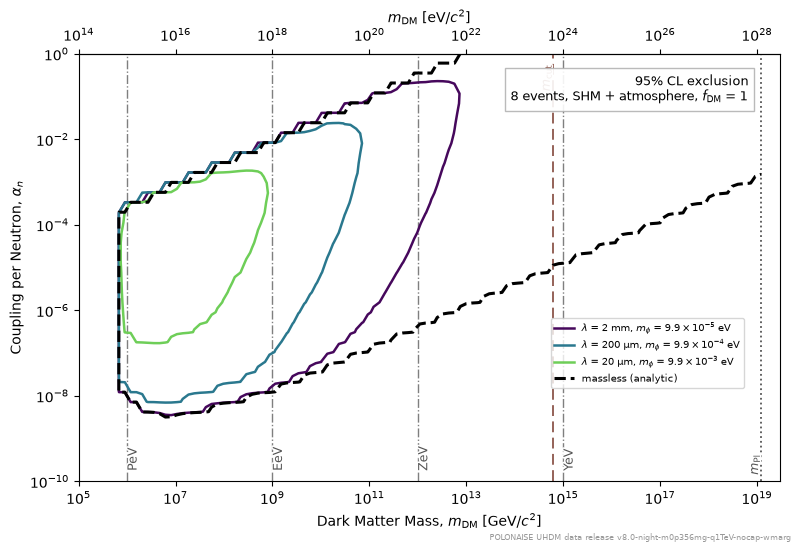

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5))
CS95 = {}
for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS or tag in HIDE:
        continue
    s = SCANS[tag]
    style = dict(linestyles="--", linewidths=2.2) if lamb is None else \
        dict(linewidths=1.8)
    lab = ("massless (analytic)" if lamb is None
           else range_legend(lamb))
    if (s["extremeness"] >= CONFIDENCE).any():
        CS95[tag] = ax.contour(s["ms"], s["alphas_n"], s["extremeness"],
                               levels=[CONFIDENCE], colors=color, **style)
        ax.plot([], [], color=color, lw=style["linewidths"],
                ls="--" if lamb is None else "-", label=lab)
    else:
        ax.plot([], [], color=color, lw=1.8, label=lab + " (no exclusion)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(REF["ms"].min(), XMAX_MASS)
ax.set_ylim(REF["alphas_n"].min(), 1.0)
ax.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
mark_mass_milestones(ax, REF["ms"].min(), XMAX_MASS)
mark_m_cut(ax)
mark_planck_mass(ax, REF["ms"][-1])
sec = ax.secondary_xaxis("top", functions=(lambda x: x * 1e9,
                                            lambda x: x / 1e9))
sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
n_shown = len([t for t, _, _ in LAMBDAS if t not in HIDE])
ax.text(0.955, 0.955,
        f"{CONFIDENCE:.0%} CL exclusion\n"
        f"{EVENTS.size} events, SHM + atmosphere, {F_DM_TXT}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(fc="white", ec="0.7", alpha=0.9))
ax.legend(loc="center right", bbox_to_anchor=(0.955, 0.30), fontsize=7)
fig.tight_layout()
save_figure(fig, "01_all_mediator_ranges")

for tag, lamb, color in ALL_TAGS:
    if tag not in SCANS:
        continue
    s = SCANS[tag]
    excl = s["extremeness"] >= CONFIDENCE
    if excl.any():
        m_ex = np.broadcast_to(s["ms"], excl.shape)[excl]
        a_ex = np.broadcast_to(s["alphas_n"][:, None], excl.shape)[excl]
        keep = m_ex <= M_CUT
        print(f"{tag:>6}: m in [{m_ex.min():.1e}, {m_ex.max():.1e}] GeV, "
              f"alpha_n down to {a_ex.min():.1e}"
              + ("" if keep.all() else
                 f"  (inside m_cut: up to {m_ex[keep].max():.1e} GeV)"))
    else:
        print(f"{tag:>6}: no exclusion (max p = {s['extremeness'].max():.2f}, "
              f"max mu = {s['counts'].max():.2f})")

### The refined boundary, and the grid it came from

Every contour above is drawn from the cube, and the cube is a grid: the
extremeness is stored on 44 couplings by 119 masses, cells 0.233 dex wide in
$\alpha_n$ and 0.119 dex in mass. Wherever the 95% level falls *inside* a cell
the drawn contour has to guess where — by interpolating in $\log_{10}\alpha_n$
between the two cells that bracket the crossing, the convention
`release/README.md` §5.3 spells out. The release now also ships the crossing
itself, found rather than interpolated:
`release/luhdm_contours_v8_A_f1_atm.json`, one refined (floor, ceiling) polyline
per surface of this file, written by `scripts/refine_contours.py` and
checksummed with the cubes in `release/SHA256SUMS`.

**What refinement is**, in four steps:

- **The same statistic.** It root-finds the 95% crossing of the optimum-interval
  extremeness — the same quantity, computed the same way, with the same
  candidates, efficiency, seed and fiducials, all read back out of the cube being
  refined. It is not a smoothing, a fit, or a second analysis.
- **Bisection between the bracketing cells.** At each mass column the two cells
  that straddle the floor (and the ceiling, where the column has one) start a
  bisection in $\log\alpha_n$ that stops once the edge is pinned to 0.005 dex, a
  fiftieth of a cell.
- **Extra mass columns where an edge jumps.** Where neighbouring columns' edges
  differ by more than 0.05 dex the boundary is moving faster than the mass axis
  samples it, so a column is inserted between them and refined the same way,
  recursively, down to 0.01 dex in mass. The massless polyline ends up with 112
  vertices on the cube's own mass columns and 116 inserted between them.
- **The ends traced in mass.** Where an island stops there is no coupling
  crossing left to bisect: the question becomes whether *anything* is excluded at
  a given mass, which is a bisection along the mass axis instead. That is what
  puts the left end of the massless island between two grid columns rather than
  at the first column that happens to be excluded.

**Two things not to mistake.** First, every refined vertex is the cube's own
arithmetic: run the refining calculation at a point the cube already carries and
it returns the stored number bit for bit at the file's `float32` storage — the
production run re-checked six such cells per surface and found no difference at
all. Refinement buys resolution, not a different answer. Second, the 95% level is
taken at that same storage precision: extremeness is stored as `float32`, so both
boundaries below test against the level narrowed to what the file can represent,
and a value sitting exactly on 0.95 counts as excluded either way.

**Which of the two is the limit.** The Letter quotes the **refined** boundary —
the massless floor it reports, $2.57\times10^{-9}$ at $7.1\times10^{6}$ GeV, is a
root-found number — while the **grid** is what the released files store: open the
cube and you get grid values, contour them and you get the dashed line below. The
two are the same claim at different resolution, and the gap between them is
bounded by the cell size.

**What moves.** The refined region is a little wider than the grid contour
everywhere: the floor drops by up to 0.176 dex (median 0.071) and the ceiling
rises by up to 0.219 dex (median 0.106), both inside one 0.233 dex coupling cell.
Both edges move outwards for the same reason — the extremeness saturates towards
1 in the interior of the region, so a straight line drawn between two cells cuts
the corner and lands inside the true edge. The difference is periodic rather than
noisy (the sawtooth in the lower panel): it vanishes wherever the crossing
happens to fall on a grid coupling and peaks when it falls mid-cell. On the left
the change is not a shift but an extension, because a grid contour cannot begin
before the first mass column that is excluded at all: that column is
$6.85\times10^{5}$ GeV, while the island really ends at $5.87\times10^{5}$ GeV,
0.067 dex lower and that much closer to the kinematic wall. Above
$\sim6\times10^{12}$ GeV there is no ceiling left to compare — the excluded band
leaves the top of the coupling axis, saturating in the cube and stored as a
`null` ceiling in the sidecar.

refined-contour sidecar release/luhdm_contours_v8_A_f1_atm.json (v8.0-night-m0p356mg-q1TeV-nocap-wmarg)
  95% level 0.949999988079071; coupling edges root-found to 0.005 dex, mass columns inserted down to 0.01 dex
  oracle re-evaluated 6 released grid cells per surface: max |d extremeness| = 0 (float32 storage)
  massless_f1: 230 vertices (112 on the cube's mass columns, 116 inserted, 106 open-topped), 2873 oracle calls
      20um_f1: 116 vertices (25 on the cube's mass columns, 85 inserted, 0 open-topped), 2092 oracle calls
     200um_f1: 215 vertices (43 on the cube's mass columns, 169 inserted, 0 open-topped), 3883 oracle calls
       2mm_f1: 247 vertices (59 on the cube's mass columns, 182 inserted, 0 open-topped), 4344 oracle calls


left end: refined tip 5.868e+05 GeV vs first excluded grid column 6.849e+05 GeV (0.067 dex); bracketed in mass between 5.768e+05 GeV (nothing excluded) and 5.868e+05 GeV (still excluded)
right end: still excluded at the last mass the cube carries, so there is no tip to trace -- m_cut closes this island, not the surface
deepest floor: refined 2.570e-09 at 7.085e+06 GeV vs grid 3.065e-09 at 6.175e+06 GeV
floor moved down by up to 0.176 dex (median 0.071); ceiling up by up to 0.219 dex (median 0.106); one coupling cell is 0.233 dex


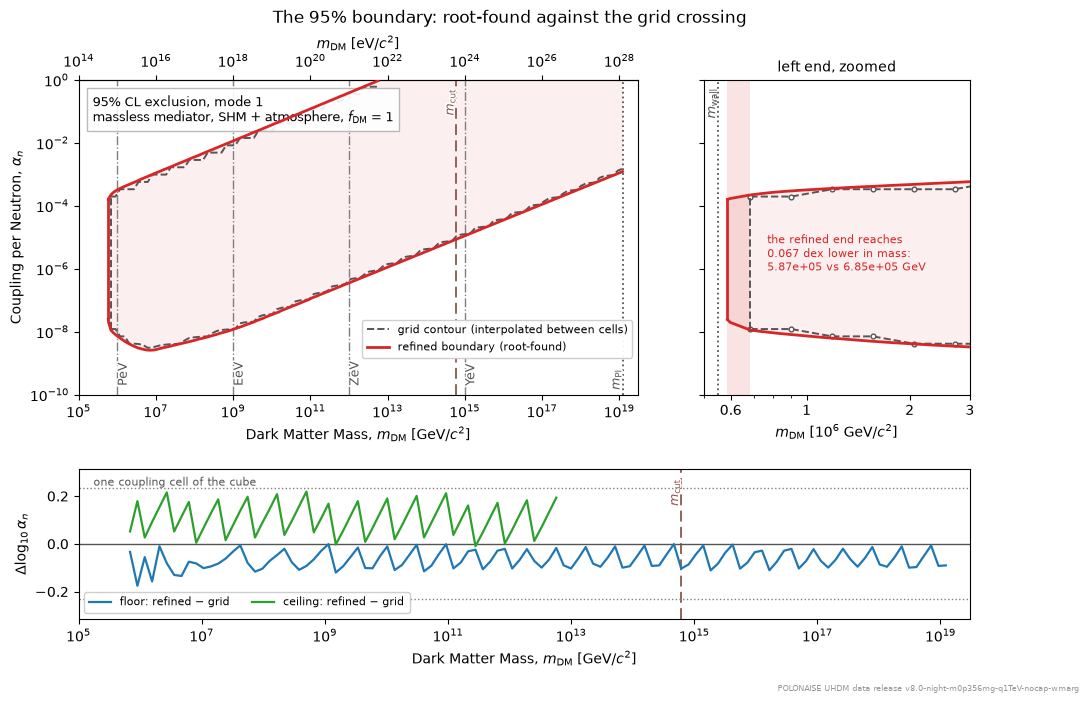

In [6]:
import json

# ---- the refined-contour sidecar: the same crossing, root-found ------------
# The cube samples the extremeness on a coarse (alpha_n x mass) grid, and the
# 95% contours above are that grid's interpolated crossing. The release ships
# the crossing itself as well -- one (floor, ceiling) polyline per surface of
# file A, root-found on the same statistic by scripts/refine_contours.py and
# checksummed in release/SHA256SUMS with the cubes. Nothing here recomputes any
# physics: the sidecar is read, not remade.
CONTOURS = Path("../release/luhdm_contours_v8_A_f1_atm.json")

# The 95% level at the release's storage-precision convention: the cube stores
# extremeness as float32, so the level is narrowed before comparing and a value
# sitting exactly on 0.95 still counts as excluded. The refinement root-finds
# that same narrowed level, so the two boundaries below are the same test.
LEVEL = float(np.float32(CONFIDENCE))

REFINED = None
if not CONTOURS.exists():
    print(f"SKIPPED: no refined-contour sidecar at release/{CONTOURS.name}")
else:
    DOC = json.loads(CONTOURS.read_text())
    PROV_C = DOC["provenance"]
    # Which cube was refined, and in which scheme: both are read off the
    # sidecar's own provenance record rather than trusted, so a file refined
    # against another cube cannot be drawn on top of contours from this one.
    assert DOC["format"] == "luhdm-refined-contours", "not a refined-contour file"
    assert DOC["confidence"] == CONFIDENCE, "the sidecar is a different level"
    assert Path(PROV_C["cube_path"]).name == rel.path.name, \
        "the sidecar refines a different released cube"
    assert PROV_C["cube_version_tag"] == rel.version_tag, \
        "the sidecar refines a different version of the cube"
    assert PROV_C["q_thresh_gev"] == float(Q_THRESH), \
        "the sidecar was refined in a different analysis window"
    assert PROV_C["b_constrained_max_m"] is None, \
        "the sidecar caps the impact-parameter integral; the release does not"
    _sums = dict(ln.split()[::-1] for ln in
                 (CONTOURS.parent / "SHA256SUMS").read_text().splitlines()
                 if len(ln.split()) == 2)
    assert CONTOURS.name in _sums, "the sidecar is not checksummed in SHA256SUMS"
    assert _sums[rel.path.name] == PROV_C["cube_sha256"], \
        "the sidecar names a cube checksum the release does not record"
    # The cube it names is the file this notebook opened, so that cube's tag is
    # the sidecar's version too, and it stamps the figure below.
    CONT_TAG = PROV_C["cube_version_tag"]
    REFINED = DOC["surfaces"]["massless_f1"]

    print(f"refined-contour sidecar release/{CONTOURS.name} ({CONT_TAG})")
    print(f"  95% level {LEVEL!r}; coupling edges root-found to "
          f"{PROV_C['tolerances']['tol_alpha_dex']:g} dex, mass columns "
          f"inserted down to {PROV_C['tolerances']['mass_res_dex']:g} dex")
    print(f"  oracle re-evaluated {PROV_C['spot_n_cells']} released grid cells "
          f"per surface: max |d extremeness| = "
          f"{max(PROV_C['spot_max_dp'].values()):g} (float32 storage)")
    for _tag, _s in DOC["surfaces"].items():
        print(f"  {_tag:>11}: {len(_s['mass_gev']):3d} vertices "
              f"({_s['n_grid_columns']} on the cube's mass columns, "
              f"{_s['n_inserted']} inserted, "
              f"{_s['n_open_top_columns']} open-topped), "
              f"{_s['n_oracle_calls']} oracle calls")


def refined_vs_grid(surf, tag, figname):
    """The refined boundary over the grid-interpolated one, for one surface."""
    ms, alphas_n = rel.axes.mass_gev, rel.axes.alpha_n
    # the grid boundary: the release's own convention (README section 5.3), the
    # level crossing interpolated in log10(alpha_n) between bracketing cells
    lo = np.full(ms.size, np.nan)
    hi = np.full(ms.size, np.nan)
    for i, m in enumerate(ms):
        lo[i], hi[i] = rel.excluded_alpha_band(m, tag, mode=MODE_NUMBER,
                                               f_dm=F_DM, confidence=CONFIDENCE)
    # a ceiling that saturates at the top of the coupling axis is not a
    # crossing: those columns are open-topped and have nothing to refine
    hi = np.where(hi >= alphas_n[-1], np.nan, hi)

    rm = np.asarray(surf["mass_gev"], dtype=float)
    rf = np.asarray(surf["floor_alpha_n"], dtype=float)
    rc = np.asarray([np.nan if c is None else c
                     for c in surf["ceiling_alpha_n"]], dtype=float)
    cell_dex = surf["cell_dex"]          # one coupling cell of the cube

    # the two boundaries on the same mass columns, for the difference panel:
    # the refined polyline read at each grid column, in decades of coupling
    lg = np.log10
    on_grid = np.isfinite(lo)
    d_floor = np.interp(lg(ms[on_grid]), lg(rm), lg(rf)) - lg(lo[on_grid])
    fin = np.isfinite(rc)
    on_ceil = np.isfinite(hi) & (ms <= rm[fin].max())
    d_ceil = np.interp(lg(ms[on_ceil]), lg(rm[fin]), lg(rc[fin])) - lg(hi[on_ceil])

    fig = plt.figure(figsize=(11.5, 7.0))
    gs = fig.add_gridspec(2, 2, height_ratios=[2.1, 1.0], width_ratios=[2.1, 1.0],
                          hspace=0.32, wspace=0.16)
    ax = fig.add_subplot(gs[0, 0])
    axz = fig.add_subplot(gs[0, 1])
    axd = fig.add_subplot(gs[1, :])

    i0 = int(np.argmax(on_grid))          # first mass column with an exclusion
    for a, zoom in ((ax, False), (axz, True)):
        a.fill_between(rm, rf, np.where(np.isfinite(rc), rc, alphas_n[-1]),
                       color="#d62728", alpha=0.07, lw=0, zorder=0)
        a.plot(ms, lo, color="#555555", lw=1.4, ls="--", zorder=3,
               marker="o" if zoom else None, ms=3.4, mfc="white")
        a.plot(ms, hi, color="#555555", lw=1.4, ls="--", zorder=3,
               marker="o" if zoom else None, ms=3.4, mfc="white")
        # each boundary closes on the left at its own left end: the grid one
        # can only start at a mass column, the refined one at the island tip
        a.plot([ms[i0]] * 2, [lo[i0], hi[i0]], color="#555555", lw=1.4,
               ls="--", zorder=3)
        a.plot(rm, rf, color="#d62728", lw=2.0, zorder=4)
        a.plot(rm, rc, color="#d62728", lw=2.0, zorder=4)
        a.plot([rm[0]] * 2, [rf[0], rc[0]], color="#d62728", lw=2.0, zorder=4)
        a.set_xscale("log")
        a.set_yscale("log")
        a.set_ylim(alphas_n.min(), 1.0)
        a.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
    ax.set_xlim(ms.min(), XMAX_MASS)
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
    mark_mass_milestones(ax, ms.min(), XMAX_MASS)
    mark_m_cut(ax)
    mark_planck_mass(ax, ms[-1])
    sec = ax.secondary_xaxis("top", functions=(lambda x: x * 1e9,
                                                lambda x: x / 1e9))
    sec.set_xlabel(r"$m_{\rm DM}$ [eV/$c^2$]")
    ax.plot([], [], color="#555555", lw=1.4, ls="--",
            label="grid contour (interpolated between cells)")
    ax.plot([], [], color="#d62728", lw=2.0,
            label="refined boundary (root-found)")
    # kept clear of the m_Pl label, which sits along the bottom spine
    ax.legend(loc="lower right", bbox_to_anchor=(1.0, 0.10), fontsize=8,
              framealpha=0.95)
    ax.text(0.025, 0.955,
            f"{CONFIDENCE:.0%} CL exclusion, mode {MODE_NUMBER}\n"
            f"massless mediator, SHM + atmosphere, {F_DM_TXT}",
            transform=ax.transAxes, ha="left", va="top", fontsize=9,
            bbox=dict(fc="white", ec="0.7", alpha=0.9))

    # the zoom: the left end, where the grid boundary can only start at a mass
    # column and the refined one is carried down to the island tip
    axz.set_xlim(5.0e5, 3.0e6)
    axz.set_xticks([6e5, 1e6, 2e6, 3e6])
    axz.set_xticklabels(["0.6", "1", "2", "3"])
    axz.set_xlabel(r"$m_{\rm DM}$ [$10^{6}$ GeV/$c^2$]")
    axz.axvspan(rm[0], ms[i0], color="#d62728", alpha=0.13, lw=0, zorder=0.5)
    axz.axvline(M_WALL, color="#555555", lw=1.3, ls=":", zorder=1)
    axz.text(M_WALL, 0.985, r"$m_{\mathrm{wall}}$ ", color="#555555", fontsize=9,
             ha="right", va="top", rotation=90, zorder=1.5,
             transform=axz.get_xaxis_transform())
    axz.text(ms[i0] * 1.12, 3e-6,
             f"the refined end reaches\n{np.log10(ms[i0] / rm[0]):.3f} dex lower "
             f"in mass:\n{rm[0]:.3g} vs {ms[i0]:.3g} GeV",
             color="#d62728", fontsize=8, ha="left", va="center")
    axz.set_title("left end, zoomed", fontsize=10, pad=6)
    axz.tick_params(labelleft=False)

    # the difference: refined minus grid, in decades of coupling
    axd.axhline(0.0, color="#555555", lw=1.0)
    for s in (+1, -1):
        axd.axhline(s * cell_dex, color="#7f7f7f", lw=1.0, ls=":")
    axd.text(ms.min() * 1.5, cell_dex, " one coupling cell of the cube",
             color="#555555", fontsize=8, ha="left", va="bottom")
    axd.plot(ms[on_grid], d_floor, color="#1f77b4", lw=1.6,
             label="floor: refined $-$ grid")
    axd.plot(ms[on_ceil], d_ceil, color="#2ca02c", lw=1.6,
             label="ceiling: refined $-$ grid")
    axd.set_xscale("log")
    axd.set_xlim(ms.min(), XMAX_MASS)
    axd.set_ylim(-1.35 * cell_dex, 1.35 * cell_dex)
    axd.set_xlabel(r"Dark Matter Mass, $m_{\rm DM}$ [GeV/$c^2$]")
    axd.set_ylabel(r"$\Delta \log_{10}\alpha_n$")
    axd.legend(loc="lower left", fontsize=8, ncols=2, framealpha=0.95)
    mark_m_cut(axd, y=0.96)

    fig.suptitle("The 95% boundary: root-found against the grid crossing",
                 fontsize=12)
    save_figure(fig, figname, stamp=CONT_TAG, bbox_inches="tight")

    # what the refinement moved, in numbers
    _left, _right = surf["tips"]["left"], surf["tips"]["right"]
    print(f"left end: refined tip {rm[0]:.3e} GeV vs first excluded grid column "
          f"{ms[i0]:.3e} GeV ({np.log10(ms[i0] / rm[0]):.3f} dex); bracketed in "
          f"mass between {_left['m_not_excluded']:.3e} GeV (nothing excluded) "
          f"and {_left['m_excluded']:.3e} GeV (still excluded)")
    if _right.get("open_at_mass_axis_edge"):
        print("right end: still excluded at the last mass the cube carries, so "
              "there is no tip to trace -- m_cut closes this island, not the "
              "surface")
    print(f"deepest floor: refined {rf.min():.3e} at "
          f"{rm[int(np.argmin(rf))]:.3e} GeV vs grid {np.nanmin(lo):.3e} at "
          f"{ms[int(np.nanargmin(lo))]:.3e} GeV")
    print(f"floor moved down by up to {-d_floor.min():.3f} dex "
          f"(median {-np.median(d_floor):.3f}); ceiling up by up to "
          f"{d_ceil.max():.3f} dex (median {np.median(d_ceil):.3f}); "
          f"one coupling cell is {cell_dex:.3f} dex")


if REFINED is not None:
    refined_vs_grid(REFINED, "massless", "01_refined_vs_grid")

### Sensitivity vs mediator range at the best mass

Fixing $m_\text{DM}$ at the mass that gives the **widest exclusion in the
$(\alpha_n, \lambda)$ plane** — chosen to reach the shortest mediator length
(the shared criterion `luhdm.release.best_mass_index`, also used per mode in
notebook 04) — and scanning the mediator range $\lambda$ against the coupling
$\alpha_n$ (down to $10^{-10}$), with this mode's detection efficiency folded
in. The excluded band is bounded below by the statistics floor, which deepens
with range and levels off at the Coulomb value once $\lambda \gtrsim$ mm (the
momentum cap stops mattering), and above by the atmospheric ceiling, which is
nearly $\lambda$-independent (atmospheric stopping is set by scattering off air
nuclei, not by the sensor). The band **pinches off** where the rising floor
meets the ceiling as $\lambda$ shrinks: below that range this mass is
untestable at any coupling, which is why the shortest-range channels return
nulls in the internal full-lambda scan.

This figure needs the **continuous $\lambda$ grid** (54 finite ranges from
$0.1\ \mu$m to 2 m), which lives in the internal full-lambda cube rather than in
a released file, whose finite axis is four points wide. That cube also has to
have been built in the same scheme as the released one — the 1 TeV analysis
window, an uncapped impact-parameter integral, and the same efficiency table —
so the cell below reads those conditions off its attributes and reports a skip
unless they hold, rather than drawing an older scheme's numbers on top of
figures that came from this one. No cube meeting them was on hand for this run,
so the cell prints its reason and writes no figure; the paragraph above
describes what that scan would show. Notebook 04 repeats the scan per mode (with
a 1–20 µm zoom that resolves exactly where the pinch-off sits) from the same
internal grid, under the same guard.

In [7]:
# best mass = widest 95% CL exclusion in the (alpha, lambda) plane, prioritizing
# reach to the shortest mediator length. The criterion lives in
# luhdm.release.best_mass_index (shared with notebook 04 so the two cannot drift).
#
# This figure scans the mediator range continuously, so it needs a cube with the
# full finite-lambda axis: the released files carry the three physics ranges and
# one convergence slice, far too few to draw the band or place its pinch-off.
# The published figure derives from the internal full-lambda cube -- and that
# cube has to have been built in the same scheme as the released ones: the 1 TeV
# analysis window, an uncapped impact-parameter integral, and the same
# efficiency table. Existence is not enough, so every condition is read off the
# candidate cube's own attributes and a cube left over from an earlier scheme is
# skipped rather than silently drawn on top of figures that came from this one.
FULL_LAMBDA_PATH = Path(release.DEFAULT_PATH)
SKIP_MSG = ("SKIPPED: no internal full-lambda cube built in the scheme this "
            "notebook reads; regenerate it before drawing this figure.")
EFF_SHA = rel.attrs.get("efficiency_npz_sha256")


def full_lambda_release(min_finite=8):
    """The internal full-lambda cube, or None (with the reason printed)."""
    if not FULL_LAMBDA_PATH.exists():
        print(f"{SKIP_MSG}\n   (no cube at release/{FULL_LAMBDA_PATH.name})")
        return None
    r = release.open_release(FULL_LAMBDA_PATH)
    q_thresh = float(r.attrs.get("q_thresh_gev", float("nan")))
    why = []
    if r.axes.n_finite < min_finite:
        why.append(f"only {r.axes.n_finite} finite mediator ranges, fewer than "
                   f"the {min_finite} a continuous scan needs")
    if q_thresh != float(Q_THRESH):
        why.append(f"analysis window {q_thresh:g} GeV, not {Q_THRESH:g} GeV")
    if r.b_constrained_max is not None:
        why.append(f"impact-parameter integral capped at {r.b_constrained_max:g} m")
    if r.attrs.get("efficiency_npz_sha256") != EFF_SHA:
        why.append("built against a different efficiency table")
    if why:
        print(f"{SKIP_MSG}\n   ({r.version_tag}: " + "; ".join(why) + ")")
        r.close()
        return None
    print(f"internal full-lambda cube {r.version_tag}: {r.axes.n_finite} finite "
          "ranges, matches the current scheme")
    return r


REL_LAM = full_lambda_release()
if REL_LAM is None:
    print(f"01_sensitivity_vs_range: {SKIP_MSG}")
else:
    M_BEST, IM_BEST = REL_LAM.best_mass(MODE_NUMBER, f_dm=F_DM)
    print(f"best mass m_DM = {M_BEST:.2e} GeV")

    # lambda scan at the best mass: the (alpha_n, lambda) extremeness / counts planes.
    lambs_l = REL_LAM.axes.lambda_finite
    alphas_l = REL_LAM.axes.alpha_n
    p_l = REL_LAM.lambda_plane("extremeness", MODE_NUMBER, mass=M_BEST,
                               f_dm=F_DM)
    mu_l = REL_LAM.lambda_plane("mu", MODE_NUMBER, mass=M_BEST, f_dm=F_DM)
    m_fixed = M_BEST

    fig, ax = plt.subplots(figsize=(7, 5))
    mesh = ax.pcolormesh(lambs_l, alphas_l, p_l, cmap="Blues", vmin=0, vmax=1,
                         shading="auto")
    fig.colorbar(mesh, ax=ax, label="optimum-interval extremeness")
    CS95_L = ax.contour(lambs_l, alphas_l, p_l, levels=[CONFIDENCE],
                        colors="#d62728", linewidths=2)
    ax.contour(lambs_l, alphas_l, mu_l, levels=[3.0], colors="#555555",
               linewidths=1.4, linestyles="--")
    ax.plot([], [], color="#d62728", lw=2,
            label=f"{CONFIDENCE:.0%} CL optimum interval ({EVENTS.size} events)")
    ax.plot([], [], color="#555555", lw=1.4, ls="--",
            label=r"$\langle N\rangle = 3$")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"Mediator Range, $\lambda$ [m]")
    ax.set_ylabel(r"Coupling per Neutron, $\alpha_n$")
    secax = ax.secondary_xaxis(
        "top", functions=(lambda x: 1e9 / units.conv_m2pGeV(x),
                          lambda x: 1e9 / units.conv_m2pGeV(1.0) / x))
    secax.set_xlabel(r"Mediator Mass, $m_\phi$ [eV/$c^2$]")

    # SI-prefix milestones that land inside the plotted mass window
    SI_EV = [(1e-24, "yeV"), (1e-21, "zeV"), (1e-18, "aeV"), (1e-15, "feV"),
             (1e-12, "peV"), (1e-9, "neV"), (1e-6, "µeV"), (1e-3, "meV"),
             (1.0, "eV")]
    lam_of_ev = lambda m_ev: 1e9 / units.conv_m2pGeV(1.0) / m_ev  # lambda [m]
    for m_ev, name in SI_EV:
        lam_mark = lam_of_ev(m_ev)
        if lambs_l.min() < lam_mark < lambs_l.max():
            ax.axvline(lam_mark, color="#7f7f7f", lw=1.0, ls="-.", zorder=1)
            ax.text(lam_mark, 0.72, f" {name}", color="#555555", fontsize=9,
                    ha="left", va="bottom", rotation=90,
                    transform=ax.get_xaxis_transform())
    e_b = int(np.floor(np.log10(m_fixed)))
    ax.text(0.975, 0.96,
            rf"$m_{{\rm DM}} = {m_fixed / 10**e_b:.1f}\times10^{{{e_b}}}$ GeV",
            transform=ax.transAxes, ha="right", va="top", fontsize=10,
            bbox=dict(fc="white", ec="0.7", alpha=0.9))
    ax.legend(loc="upper left", fontsize=8)
    fig.tight_layout()
    save_figure(fig, "01_sensitivity_vs_range", stamp=REL_LAM.version_tag)

SKIPPED: no internal full-lambda cube built in the scheme this notebook reads; regenerate it before drawing this figure.
   (no cube at release/luhdm_datarelease_v5.h5)
01_sensitivity_vs_range: SKIPPED: no internal full-lambda cube built in the scheme this notebook reads; regenerate it before drawing this figure.


## Machine-readable output

Every surface, contour, and event list on the plots above lives in the
POLONAISE UHDM **data release** (the current release cube — see the version
tag in the file / `release/README.md`), read here
through `luhdm.release`. See
[`06_datarelease.ipynb`](06_datarelease.ipynb) for the schema, the loader API,
and how to pull any slice (including the raw-HDF5 route with no luhdm code).

## Notes

- **Data**: replace `data_mode{n}.txt` and re-run. More candidates only move
  the extremeness surfaces; the machinery is untouched.
- Every surface here is precomputed once by **`scripts/build_release.py`** (the
  per-$\lambda$ cube builder, run on a many-core node) and assembled into the
  HDF5 data release by **`scripts/assemble_release.py`**; this notebook only
  *reads* it through **`luhdm.release`**, so notebook and cluster runs cannot
  drift. The underlying physics lives in **`luhdm/rate.py`** and the fiducials in
  **`luhdm/config.py`** (threshold, exposure, $f_X$, …).
- The $\langle N\rangle \simeq 3$ dashed contour is the zero-candidate rule; the
  solid optimum-interval contour reduces to it only where no candidate falls in
  the kinematic window.